In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit, prange
import os
import time

In [2]:
@jit(nopython=True, fastmath=True,cache=True)
def kolchinsky(T, Y, sigma2:float):  #nats units

    T = T.astype(np.float32)           #a matrix of shape (n_samples, n_features); features are neurons
    sigma2 = np.float32(sigma2)
    
    n_samples, n_features = T.shape   
    
    norms2 = np.zeros(n_samples, dtype=np.float32) #initializing squares of euclidean norms of rows of T (i need only squares); array of scalars
    for i in range(n_samples):                     #for each row
        norm = np.float32(0.0)                     #initializing a scalar
        Ti = T[i]                                  #the i-th row of T: a vector of length n_features; faster to access it once than multiple times in inner loop
        for k in range(n_features):                #for each column (neuron)
            val = Ti[k]                            #the value of the k-th feature of the i-th sample; accessing it once 
            norm += val * val                      #norms2 of the row as temporary variable
        norms2[i] = norm                           #moving from temporary variable to array position
    
    unique_y = np.unique(Y)                        #sorted array (usually lenght 10); this reguards only Y, not T
    class_indices = []                             #list of unique_y arrays (10 arrays)
    for cls in unique_y:                           #for each label (class)
        indices = np.where(Y == cls)[0]            #the output is a tuple of arrays (one array), I need only the 0-th; cls==Y is boll, np.where gives the indices of True values
        class_indices.append(indices)              
    
    def compute_H(sigma2):                      #I(T;X)=H(T) - H(T|X)(=0); kolchinsky estimates only upper bound
        denom_up = np.float32(2.0)*sigma2       #denominator of exp; precomputing it for efficiency
        denom_low = np.float32(8.0)*sigma2
        log_sum_up = np.float32(0.0)            #initializing sum of the log (outer sum over i)
        log_sum_low = np.float32(0.0)
        
        for i in range(n_samples):              #for each row of T (i-th sample); outer sum over i
            row_sum_up = np.float32(0.0)        #the inner sum; the sum is over j, so each i has its own row_sum
            row_sum_low = np.float32(0.0)
            norm2_i = norms2[i]                 #norms2 is an array of scalars
            Ti = T[i]                           #all neurons of sample i; I will need later for the double product
            
            for j in range(n_samples):          #for the i-th sample, I consider all j-th samples; inner sum over j
                if i == j:                           #self-distance
                    row_sum_up += np.float32(1.0)    #distance is zero, exp(0)=1
                    row_sum_low += np.float32(1.0)
                else:                           #||a-b||^2 = a^2 + b^2 -2*a*b due to the development of (a-b)(a-b)
                    dot = np.float32(0.0)       #so I compute the double product; here initializing for pair i,j
                    Tj = T[j]                   #the j-th row of T;
                    for k in range(n_features): #for each neuron
                        dot += Ti[k] * Tj[k]    #scalar product
                    
                    distance = norm2_i + norms2[j] - np.float32(2.0) * dot #||a-b||^2=a^2+b^2-2*a*b due to the development of (a-b)(a-b)
                    row_sum_up += np.exp(-distance / denom_up)             #inner sum (over j)
                    row_sum_low += np.exp(-distance / denom_low)
            
            log_sum_up += np.log(row_sum_up / n_samples + np.float32(1e-12))     #outer sum (ever i: sum of the logs)
            log_sum_low += np.log(row_sum_low / n_samples + np.float32(1e-12))

        return -log_sum_up / n_samples, -log_sum_low / n_samples
    
    def compute_H_givenY(sigma2):                              #only the second term of the formula, the first is calculated in "compute_H" bcs it is the same
        denom_up = np.float32(2.0) * np.float32(1.0) * sigma2
        denom_low = np.float32(2.0) * np.float32(4.0) * sigma2
        total_up = np.float32(0.0)                  #inizializing outer sum (we have triple sum)
        total_low = np.float32(0.0)

        for class_idx in class_indices:             #for each label, array of corresponding indices
            n_class = len(class_idx)                
            if n_class > 0:                         #almost always true; if at least one sample of the class is present                
                class_sum_up = np.float32(0.0)      #initializing mid sum (we have triple sum)
                class_sum_low = np.float32(0.0)
                for i_idx in range(n_class):        #0,1,2,...,label_max; here we fix the label
                    i = class_idx[i_idx]            #if i_idx=0, it is array of indices of samples with label 0
                    row_sum_up = np.float32(0.0)    #inner sum
                    row_sum_low = np.float32(0.0)
                    norm2_i = norms2[i]              #accessing once and storing temporary; a scalar
                    Ti = T[i]                        #same, but a list      
                    for j_idx in range(n_class):     #inner sum over j (rows), 
                        j = class_idx[j_idx]
                        if i == j:                   #distance is zero, exp(0)=1
                            row_sum_up += np.float32(1.0)
                            row_sum_low += np.float32(1.0)
                        else:                        #pair-wise distance ||a-b||^2 = a^2 + b^2 -2*a*b
                            dot = np.float32(0.0)    #initializing double product
                            Tj = T[j]
                            for k in range(n_features): #computing double product
                                dot += Ti[k] * Tj[k]
                            distance = norm2_i + norms2[j] - np.float32(2.0) * dot
                            row_sum_up += np.exp(-distance / denom_up)                   #updating inner sum (over j)
                            row_sum_low += np.exp(-distance / denom_low)
                    class_sum_up += np.log(row_sum_up / n_class + np.float32(1e-12))     #updating mid sum (over i)
                    class_sum_low += np.log(row_sum_low / n_class + np.float32(1e-12))   
                total_up += -class_sum_up                                                #updating numerator outer sum (over classes)
                total_low += -class_sum_low
        return total_up / n_samples, total_low / n_samples                               #returning with denominator

    
    H_X_up, H_X_low = compute_H(sigma2)
    H_X_givenY_up, H_X_givenY_low = compute_H_givenY(sigma2)
    
    I_XY_up = H_X_up - H_X_givenY_up
    I_XY_low = H_X_low - H_X_givenY_low
    
    return (np.float32(H_X_up), np.float32(I_XY_up), np.float32(H_X_low), np.float32(I_XY_low))

In [3]:
class kolchinsky_with_sampling:                        #wrapper of kolchinsky, but in bits and with sampling
    def __init__(self, sigma2:float, sample_size:int):
        self.sigma2 = sigma2
        self.sample_size = sample_size
        
    def compute_bounds(self, T, Y):
        n_samples = T.shape[0]                                         #total samples before sampling
        
        unique_y = np.unique(Y)                                        #unique labels sorted
        samples_per_class = self.sample_size // len(unique_y)          #
        
        indices = []
        for cls in unique_y:
            cls_idx = np.where(Y == cls)[0]
            n_take = min(len(cls_idx), samples_per_class)
            chosen = np.random.choice(cls_idx, n_take, replace=False)
            indices.extend(chosen)
        
        if len(indices) > self.sample_size:
            indices = indices[:self.sample_size]
        elif len(indices) < self.sample_size:
            extra = np.random.choice(n_samples, self.sample_size - len(indices), replace=False)
            indices.extend(extra)
        
        indices = np.array(indices)
        T = T[indices]
        Y = Y[indices]
        n_samples = len(indices)
        
        H_X_up, I_XY_up, H_X_low, I_XY_low = kolchinsky(T, Y, self.sigma2)
        
        return {                                           #returns a dictionary, in bits
            'H_X_up': max(0, H_X_up / np.log(2)),            
            'I_XY_up': max(0, I_XY_up / np.log(2)),
            'H_X_low': max(0, H_X_low / np.log(2)),
            'I_XY_low': max(0, I_XY_low / np.log(2)),
            'n_samples': n_samples
        }

In [4]:
FOLDER_PATH = 'MNIST_CNN_conv_16-32_256-0_64-1_Tanh'

data = np.load(os.path.join(FOLDER_PATH, 'data.npz'))
Y_labels = data['true_labels']

layers = {}
layer_names = []

for file in sorted(os.listdir(FOLDER_PATH)):
    if file != 'data.npz':
        layer_name = file.removesuffix('.npz')
        layer_names.append(layer_name)
        layer_data = np.load(os.path.join(FOLDER_PATH, file))
        
        layer_activations = []
        n_epochs = len(layer_data.files)
        for i in range(n_epochs):
            layer_activations.append(layer_data[f'arr_{i}'])
        
        layers[layer_name] = layer_activations

In [6]:
sigma2 = 1                                       
sample_size = 4000                              
n_epochs_total = len(layers[layer_names[0]])
n_epochs_to_analyze = 100  


print("=" * 70)
print(f"σ² = {sigma2}")
print(f"Batch size for MI = {sample_size}")
print(f"H(X)_max = log2({sample_size}) = {np.log2(sample_size):.2f} bits")

analyzer = kolchinsky_with_sampling(sigma2=sigma2, sample_size=sample_size)

results = {}
for layer_name in layer_names:
    results[layer_name] = {
        'I_XT_up': [], 'I_TY_up': [], 
        'I_XT_low': [], 'I_TY_low': [],
        'epochs': []
    }

print(f"\nCalcolo MI per {n_epochs_to_analyze} epoche...")
print("=" * 50)

start_time = time.time()

for epoch in range(n_epochs_to_analyze):
    epoch_start = time.time()
    
    for layer_idx, layer_name in enumerate(layer_names):
        T = layers[layer_name][epoch]
        Y = Y_labels[:T.shape[0]]
        
        bounds = analyzer.compute_bounds(T, Y)
        
        results[layer_name]['I_XT_up'].append(bounds['H_X_up'])
        results[layer_name]['I_TY_up'].append(bounds['I_XY_up'])
        results[layer_name]['I_XT_low'].append(bounds['H_X_low'])
        results[layer_name]['I_TY_low'].append(bounds['I_XY_low'])
        results[layer_name]['epochs'].append(epoch)
    
    epoch_time = time.time() - epoch_start
    total_time_so_far = time.time() - start_time
    avg_time_per_epoch = total_time_so_far / (epoch + 1)
    
    print(f"Epoch {epoch+1:3d}/{n_epochs_to_analyze}: "
          f"{epoch_time:6.2f}s (cum: {total_time_so_far:7.1f}s, "
          f"avg: {avg_time_per_epoch:5.2f}s/ep, ")

total_time = time.time() - start_time

print(f"TOTAL TIME: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")

σ² = 1
Batch size for MI = 4000
H(X)_max = log2(4000) = 11.97 bits

Calcolo MI per 100 epoche...
Epoch   1/100:   2.70s (cum:     2.7s, avg:  2.70s/ep, 
Epoch   2/100:   1.68s (cum:     4.4s, avg:  2.19s/ep, 
Epoch   3/100:   1.70s (cum:     6.1s, avg:  2.02s/ep, 
Epoch   4/100:   1.71s (cum:     7.8s, avg:  1.94s/ep, 
Epoch   5/100:   1.73s (cum:     9.5s, avg:  1.90s/ep, 
Epoch   6/100:   1.72s (cum:    11.2s, avg:  1.87s/ep, 
Epoch   7/100:   1.73s (cum:    13.0s, avg:  1.85s/ep, 
Epoch   8/100:   1.74s (cum:    14.7s, avg:  1.84s/ep, 
Epoch   9/100:   1.74s (cum:    16.4s, avg:  1.83s/ep, 
Epoch  10/100:   1.74s (cum:    18.2s, avg:  1.82s/ep, 
Epoch  11/100:   1.73s (cum:    19.9s, avg:  1.81s/ep, 
Epoch  12/100:   1.74s (cum:    21.7s, avg:  1.80s/ep, 
Epoch  13/100:   1.75s (cum:    23.4s, avg:  1.80s/ep, 
Epoch  14/100:   1.75s (cum:    25.1s, avg:  1.80s/ep, 
Epoch  15/100:   1.75s (cum:    26.9s, avg:  1.79s/ep, 
Epoch  16/100:   1.76s (cum:    28.7s, avg:  1.79s/ep, 
Epoch  

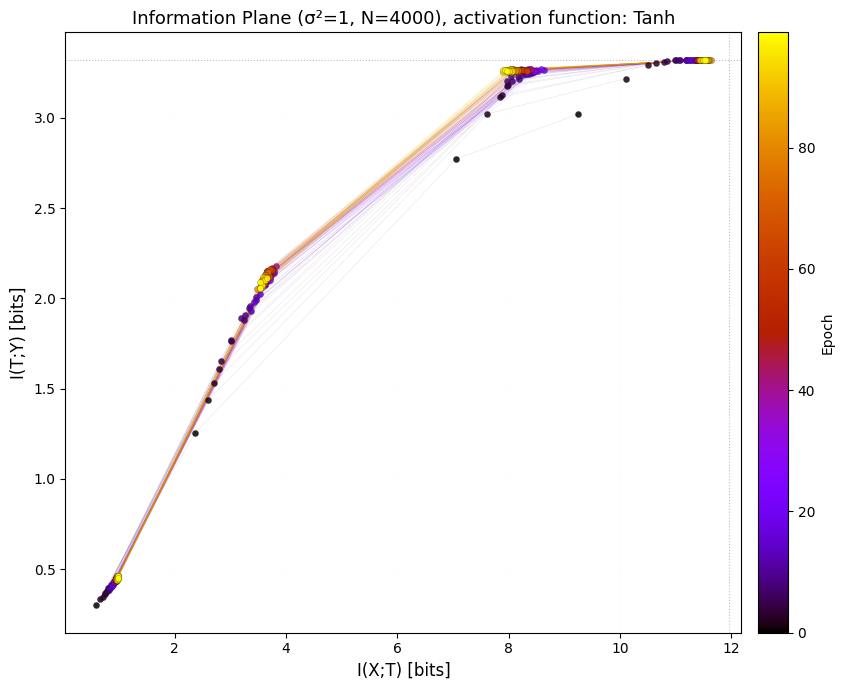

In [7]:
plt.figure(figsize=(9, 7))

colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

# 1. Plot dei PUNTI (upper bounds only)
for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        epoch_points_x.append(results[layer_name]['I_XT_up'][epoch])
        epoch_points_y.append(results[layer_name]['I_TY_up'][epoch])
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20, alpha=0.85, edgecolors='black',
               linewidth=0.15, marker='o',
               zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        points.append((results[layer_name]['I_XT_up'][epoch],
                      results[layer_name]['I_TY_up'][epoch]))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}), activation function: Tanh', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6.86
y_margin_min = 2.88
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min        #+2%
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)

plt.tight_layout()
plt.show()

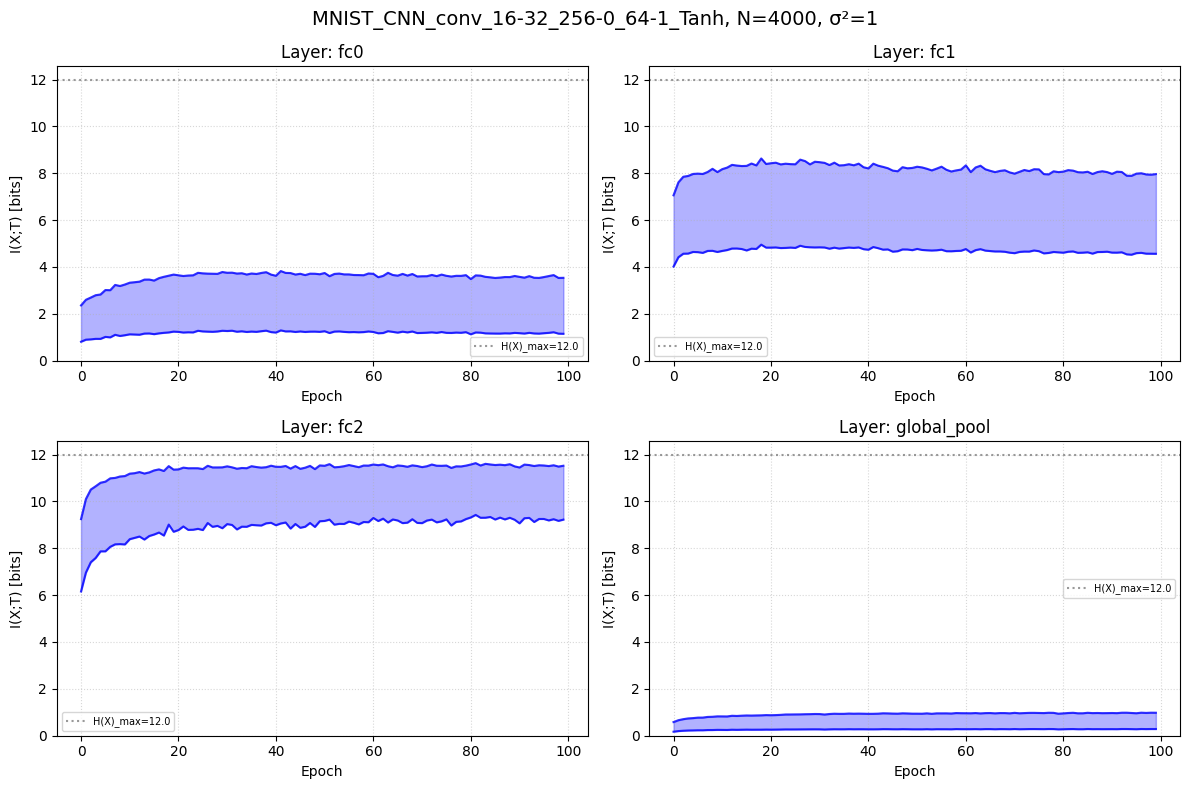

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (layer_name, ax) in enumerate(zip(layer_names, axes)):
    epochs = results[layer_name]['epochs']
    I_XT_up = results[layer_name]['I_XT_up']
    I_XT_low = results[layer_name]['I_XT_low']
    
    ax.fill_between(epochs, I_XT_low, I_XT_up, alpha=0.3, color='blue')
    
    ax.plot(epochs, I_XT_up, 'b-', linewidth=1.5, alpha=0.8)
    ax.plot(epochs, I_XT_low, 'b-', linewidth=1.5, alpha=0.8)
    
    ax.axhline(y=H_X_max, color='gray', linestyle=':',alpha=0.8, linewidth=1.5, label=f'H(X)_max={H_X_max:.1f}')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('I(X;T) [bits]', fontsize=10)
    ax.set_title(f'Layer: {layer_name}', fontsize=12)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.5, linestyle=':')
    ax.set_ylim(0, H_X_max * 1.05)

fig.suptitle(f'{FOLDER_PATH}, N={sample_size}, σ²={sigma2}', fontsize=14)
plt.tight_layout()
plt.show()

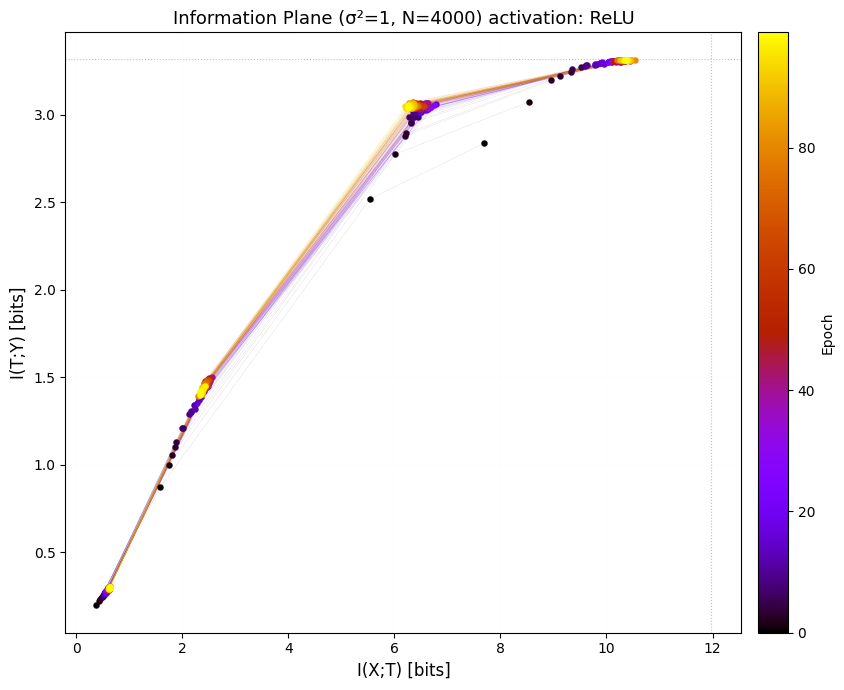

In [9]:
plt.figure(figsize=(9, 7))

# Colormap per epoche
colormap = plt.colormaps['gnuplot']
norm = plt.Normalize(0, n_epochs_to_analyze-1)

# 1. Plot dei PUNTI (media upper/lower)
for epoch in range(n_epochs_to_analyze):
    epoch_points_x = []
    epoch_points_y = []
    
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        
        epoch_points_x.append(I_XT_mean)
        epoch_points_y.append(I_TY_mean)
    
    plt.scatter(epoch_points_x, epoch_points_y,
               color=colormap(norm(epoch)),
               s=20,linewidth=0.15, marker='o', zorder=5)

# 2. Linee nere che collegano LAYERS a epoca fissata
for epoch in range(n_epochs_to_analyze):
    points = []
    for layer_name in layer_names:
        I_XT_mean = 0.5 * (results[layer_name]['I_XT_up'][epoch] +
                           results[layer_name]['I_XT_low'][epoch])
        I_TY_mean = 0.5 * (results[layer_name]['I_TY_up'][epoch] +
                           results[layer_name]['I_TY_low'][epoch])
        points.append((I_XT_mean, I_TY_mean))
    
    points.sort(key=lambda x: x[0])
    x_vals = [p[0] for p in points]
    y_vals = [p[1] for p in points]
    
    plt.plot(x_vals, y_vals, '-', color=colormap(norm(epoch)),
            alpha=0.4, linewidth=0.1, zorder=2)

# 3. Assi e labels
plt.xlabel('I(X;T) [bits]', fontsize=12)
plt.ylabel('I(T;Y) [bits]', fontsize=12)
plt.title(f'Information Plane (σ²={sigma2}, N={sample_size}) activation: ReLU', fontsize=13)

# 4. Scale con MARGINI
H_X_max = np.log2(sample_size)
max_I_TY = np.log2(10)
x_margin_min = 6
y_margin_min = 2.7
x_margin_max = ((H_X_max-x_margin_min) * 1.02) + x_margin_min
y_margin_max = ((max_I_TY-y_margin_min) * 1.02) + y_margin_min

#plt.xlim(x_margin_min, x_margin_max)  
#plt.ylim(y_margin_min, y_margin_max)  

# 5. Linee teoriche
plt.axhline(y=max_I_TY, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'Max I(T;Y)={max_I_TY:.2f}')

plt.axvline(x=H_X_max, color='gray', linestyle=':', 
           alpha=0.5, linewidth=0.8, zorder=0,
           label=f'H(X)_max={H_X_max:.2f}')

# 6. Colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label('Epoch', fontsize=10)

plt.grid(True, alpha=0.05, linestyle='-', linewidth=0.3)
plt.tight_layout()
plt.show()